# Do-Shapley (SCM connu) — Notebook complet (DoWhy GCM + NetworkX + UMAP + HDBSCAN)

Ce notebook construit un pipeline **réplicable** pour :

1. Générer des données synthétiques à partir d’un **SCM (Structural Causal Model)** explicitement défini (graphe via **NetworkX** + mécanismes causaux).
2. Calculer des **valeurs de Do‑Shapley** : attributions **interventionnelles** basées sur  
   \[
   v_{\mathrm{do}}(S;x)=\mathbb{E}[Y \mid do(X_S=x_S)].
   \]
3. Comparer à des **attributions observées** (SHAP classique sur un modèle appris).
4. Projeter (UMAP) + clusteriser (HDBSCAN) et visualiser (coloré par cluster ou par classe).

> ⚠️ Notes
> - Les Do‑Shapley ci‑dessous sont calculées par **échantillonnage Monte‑Carlo + permutations** (approximation Shapley).
> - Le SCM est supposé **connu** (comme demandé).  
> - On garde un **régime latent** `R` dans le SCM (non utilisé comme feature) afin de créer deux mécanismes explicatifs menant à des scores difficiles à distinguer marginalement.


## 0) Imports & versions

In [2]:
import numpy as np
import pandas as pd

import networkx as nx

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

import umap.umap_ as umap
import hdbscan

import shap

# DoWhy GCM (Graphical Causal Models)
from dowhy import gcm

print("numpy", np.__version__)
print("pandas", pd.__version__)
print("networkx", nx.__version__)
print("shap", shap.__version__)
print("dowhy.gcm", gcm.__package__)


numpy 1.26.4
pandas 2.1.4
networkx 3.4.2
shap 0.43.0
dowhy.gcm dowhy.gcm


## 1) Dataset: proche de ton exemple, mais avec dépendances uniformes partagées (complexification)

On crée des variables observées `X1..X6` avec **dépendances induites** par deux variables latentes continues `Z1, Z2` (partagées), et un **régime latent** `R∈{0,1}` qui inverse la logique interactionnelle.

Idée :
- `Z1` est une source uniforme commune qui influence (X1,X2,X3)
- `Z2` influence (X4,X5,X6)
- Le score dépend de `X1*X2` avec un signe différent selon `R`, et d’additifs dépendant de (X3..X6)
- On génère ensuite `Y` par un softmax/mixture inspiré de ton code.

⚠️ Important : Dans le SCM, **on encode le mécanisme** (pas seulement une fonction de score).

In [24]:
def make_dataset_overlap_scores_but_separable_interactions_complex(
    n=1500, seed=0, sigma=0.9
):
    rng = np.random.default_rng(seed)

    # Régime latent binaire
    R = rng.integers(0, 2, size=n)

    # Latents continus partagés (uniformes) -> dépendances structurelles
    Z1 = rng.uniform(-5, 5, size=n)
    Z2 = rng.uniform(-5, 5, size=n)

    # Bruits
    e = 0.25 * rng.normal(size=(6, n))

    # Variables observées (dépendantes)
    X1 =  0.9*Z1 + 0.3*Z2 + e[0]
    X2 = -0.9*Z1 + 0.2*Z2 + e[1]
    X3 =  0.7*Z1 + 0.1*Z2 + e[2]
   

    interaction = X1 * X2

    # Additifs "complexes" (même forme mais coefficients dépendent du régime via tirages U)
    U = rng.uniform(size=(8, n))
    AdditifA = -6*X1 + 6*X2 + U[0]*X3 
    AdditifB =  6*X1 - 6*X2 + U[1]*X3 

    eps = sigma * rng.normal(size=n)

    score_A =  6.0 * (-interaction) + AdditifA + eps
    score_B =  6.0 * ( interaction) + AdditifB + eps

    # Score observé utilisé pour générer Y : on choisit A ou B selon R
    score = np.where(R == 0, score_A, score_B)

    # Variante inspirée de ton softmax
    prob = np.exp(score_B) / (np.exp(score_A) + np.exp(score_B))
    Y = rng.binomial(1, prob)

    X = np.column_stack([X1, X2, X3])

    meta = {
        "R": R,
        "Z1": Z1,
        "Z2": Z2,
        "score_A": score_A,
        "score_B": score_B,
        "score": score,
        "feature_names": [f"X{i}" for i in range(1, 7)]
    }
    return X, Y, meta

X, Y, meta = make_dataset_overlap_scores_but_separable_interactions_complex(n=1000, seed=0)
feature_names = meta["feature_names"]

print("X shape:", X.shape, "Y mean:", Y.mean())


X shape: (1000, 3) Y mean: 0.271


### Visualiser que les scores A/B sont difficiles à distinguer (marginalement)

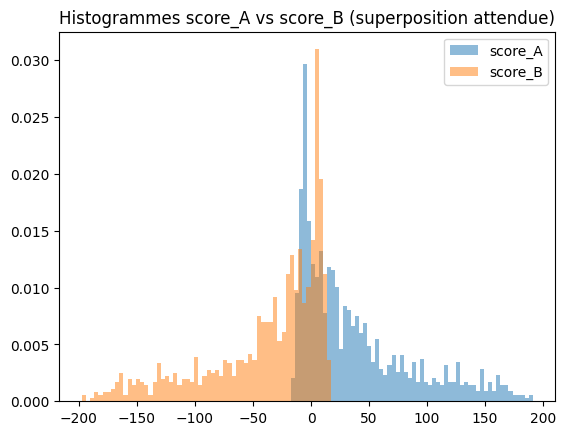

In [25]:
score_A = meta["score_A"]
score_B = meta["score_B"]

plt.figure()
plt.hist(score_A, bins=60, alpha=0.5, density=True, label="score_A")
plt.hist(score_B, bins=60, alpha=0.5, density=True, label="score_B")
plt.title("Histogrammes score_A vs score_B (superposition attendue)")
plt.legend()
plt.show()


## 2) Construire le SCM (NetworkX) + mécanismes (DoWhy GCM)

On définit explicitement un graphe causal avec des nœuds latents `Z1`, `Z2`, `R` et les nœuds observés `X1..X6`, puis `Y`.

Ensuite, on attache des mécanismes causaux *connus* (pas besoin de fitter).

In [27]:
G = nx.DiGraph()
G.add_edges_from([
    ("Z1", "X1"), ("Z1", "X2"), ("Z1", "X3"),
    ("Z2", "X1"), ("Z2", "X2"), ("Z2", "X3"),
    ("X1", "Y"), ("X2", "Y"), ("X3", "Y"),
])

def plot_scm_simple(G):
    """
    Affichage simple d'un DAG causal à la NetworkX,
    avec positions fixes et lisibles (style article / cours).
    """

    # Séparer les types de noeuds
    latents = [n for n in G.nodes if n.startswith("Z") or n == "R"]
    observeds = [n for n in G.nodes if n.startswith("X")]
    target = ["Y"] if "Y" in G.nodes else []

    pos = {}

    # Latents à gauche
    for i, n in enumerate(sorted(latents)):
        pos[n] = (-1.5, 0.8 - i)

    # Observés au centre
    for i, n in enumerate(sorted(observeds)):
        pos[n] = (0, 1.2 - 0.4 * i)

    # Target à droite
    if target:
        pos["Y"] = (1.5, 0)

    plt.figure(figsize=(8, 4))
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=2200,
        arrowsize=18,
        node_color="#E0E0E0",
        edgecolors="black",
        linewidths=1.5,
        font_size=11
    )
    plt.title("DAG causal (SCM)")
    plt.axis("off")
    plt.show()



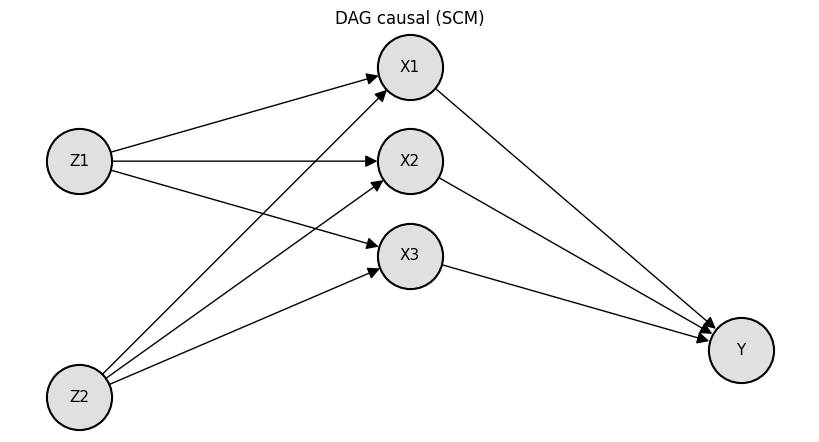

In [7]:
plot_scm_simple(G)


In [28]:
# 2.2 Définition des mécanismes causaux (SCM connu)
scm = gcm.StructuralCausalModel(G)
df = pd.DataFrame(
    X, columns=[f"X{i}" for i in range(1,4)]
)
df["Y"] = Y
df["Z1"] = meta["Z1"]
df["Z2"] = meta["Z2"]

rng = np.random.default_rng(0)

gcm.auto.assign_causal_mechanisms(scm, df)
gcm.fit(scm, df)

print("SCM ready.")


Fitting causal mechanism of node Y: 100%|██████████| 6/6 [00:00<00:00, 15.85it/s]

SCM ready.


## 3) Do‑Shapley : définition + approximation par permutations

On estime \(v_{\mathrm{do}}(S;x)=\mathbb{E}[Y\mid do(X_S=x_S)]\) par Monte‑Carlo et on approxime Shapley par permutations.

In [29]:
FEATURES = [f"X{i}" for i in range(1,4)]+["Z1","Z2"]
TARGET = "Y"

def estimate_v_do(scm, x_row, S, n_mc=400):
    # DoWhy veut: interventions = {node: function(array)->array}
    interventions = {name: (lambda v, c=float(x_row[name]): c) for name in S}

    interventional_samples = gcm.interventional_samples(
        scm, interventions=interventions, num_samples_to_draw=n_mc
    )
    return float(np.mean(interventional_samples[TARGET].to_numpy()))


def do_shapley_for_one(scm, x_row, features=FEATURES, n_perm=60, n_mc=250, seed=0):
    rng = np.random.default_rng(seed)
    phi = {f: 0.0 for f in features}
    cache = {}

    def v(S):
        S = tuple(sorted(S))
        if S not in cache:
            cache[S] = estimate_v_do(scm, x_row, S, n_mc=n_mc)
        return cache[S]

    for _ in range(n_perm):
        perm = rng.permutation(features)
        S = []
        v_prev = v(S)
        for f in perm:
            S.append(f)
            v_new = v(S)
            phi[f] += (v_new - v_prev)
            v_prev = v_new

    for f in features:
        phi[f] /= n_perm
    return phi

def do_shapley_matrix(scm, X_df, features=FEATURES, n_perm=60, n_mc=250, seed=0):
    rng = np.random.default_rng(seed)
    out = np.zeros((len(X_df), len(features)))
    for i in range(len(X_df)):
        phi_i = do_shapley_for_one(
            scm, X_df.iloc[i], features=features,
            n_perm=n_perm, n_mc=n_mc,
            seed=int(rng.integers(0, 10_000_000))
        )
        out[i] = [phi_i[f] for f in features]
    return out


### Calcul Do‑Shapley sur un sous‑ensemble (coût)

In [30]:
X_df = df[FEATURES].copy()
y = df["Y"].to_numpy()

# Sous-échantillonnage (accélère fortement)
#idx = np.random.default_rng(0).choice(len(df), size=450, replace=False)
#X_sub = X_df.iloc[idx].reset_index(drop=True)
#y_sub = y[idx]
#R_sub = df.loc[idx, "R"].to_numpy()

do_phi = do_shapley_matrix(scm, X_df, n_perm=60, n_mc=250, seed=0)
print("do_phi shape:", do_phi.shape)


do_phi shape: (1000, 5)


In [31]:
df["Y"]

0      0
1      0
2      0
3      0
4      0
      ..
995    1
996    1
997    0
998    0
999    0
Name: Y, Length: 1000, dtype: int64

## 4) SHAP observé sur un modèle appris (comparaison)

SHAP observé explique le **modèle** appris, Do‑Shapley explique le **SCM** (interventions).

In [32]:
Xtr, Xte, ytr, yte = train_test_split(X_df, y, test_size=0.25, random_state=0, stratify=y)

model = HistGradientBoostingClassifier(max_depth=4, learning_rate=0.08, max_iter=250, random_state=0)
model.fit(Xtr, ytr)

pred = model.predict_proba(Xte)[:, 1]
print("AUC:", roc_auc_score(yte, pred))

expl = shap.TreeExplainer(model)
shap1_sub = expl.shap_values(X_df)

if isinstance(shap1_sub, list):
    shap1_sub = shap1_sub[1]

print("shap1_sub shape:", shap1_sub.shape)


AUC: 0.9921622495151907
shap1_sub shape: (1000, 5)


## 5) UMAP + HDBSCAN : Do‑Shapley vs SHAP observé

On réduit en 2D et on clusterise finement, puis on affiche :
- coloré par **cluster**
- coloré par **classe Y**
- (option) coloré par **régime latent R**

In [33]:
do_phi_s = StandardScaler().fit_transform(do_phi)
shap1_s  = StandardScaler().fit_transform(shap1_sub)

umap_do = umap.UMAP(n_neighbors=30, min_dist=0.05, n_components=2, random_state=0).fit_transform(do_phi_s)
umap_obs = umap.UMAP(n_neighbors=30, min_dist=0.05, n_components=2, random_state=0).fit_transform(shap1_s)

clusterer_do = hdbscan.HDBSCAN(min_cluster_size=80, min_samples=30)
labels_do = clusterer_do.fit_predict(umap_do)

clusterer_obs = hdbscan.HDBSCAN(min_cluster_size=80, min_samples=30)
labels_obs = clusterer_obs.fit_predict(umap_obs)

print("Do-Shapley clusters:", sorted(set(labels_do)))
print("Observed SHAP clusters:", sorted(set(labels_obs)))


n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


Do-Shapley clusters: [-1, 0, 1, 2, 3]
Observed SHAP clusters: [-1, 0, 1, 2, 3]


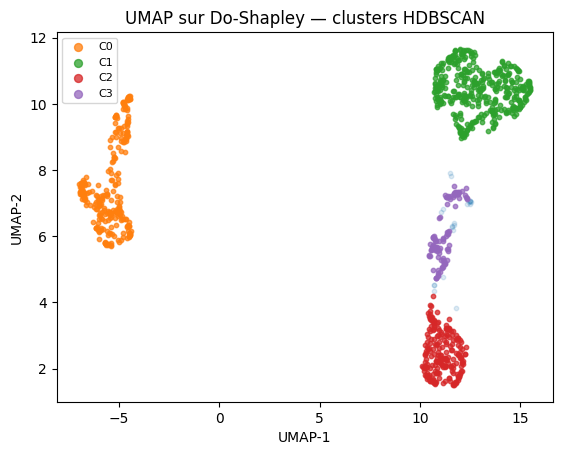

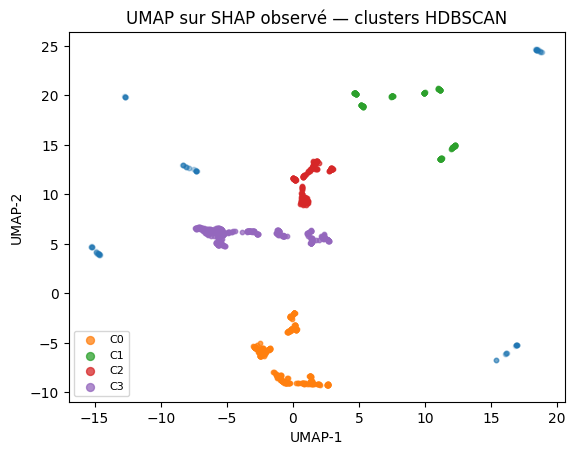

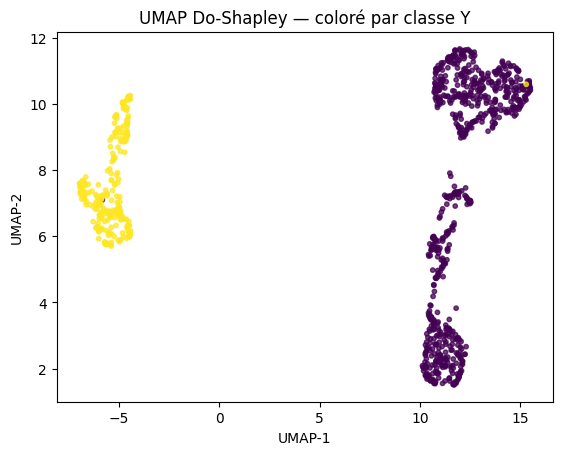

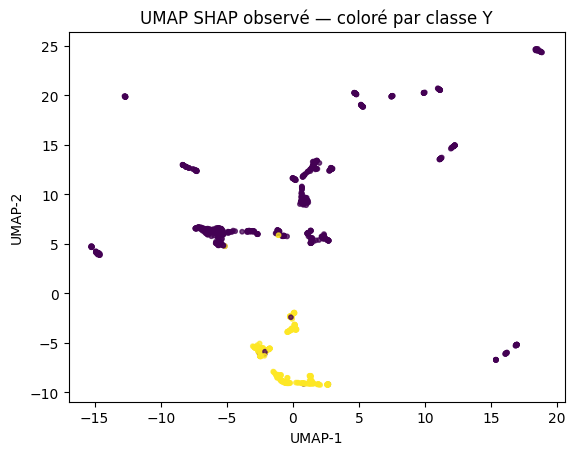

In [34]:
def scatter_2d(emb, labels=None, color=None, title=""):
    plt.figure()
    if color is not None:
        plt.scatter(emb[:,0], emb[:,1], c=color, s=10, alpha=0.75)
    elif labels is not None:
        noise = labels == -1
        plt.scatter(emb[noise,0], emb[noise,1], s=10, alpha=0.15)
        for c in sorted(set(labels)):
            if c == -1:
                continue
            idxc = labels == c
            plt.scatter(emb[idxc,0], emb[idxc,1], s=10, alpha=0.75, label=f"C{c}")
        plt.legend(fontsize=8, markerscale=1.8)
    else:
        plt.scatter(emb[:,0], emb[:,1], s=10, alpha=0.75)
    plt.title(title)
    plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
    plt.show()

# Par clusters
scatter_2d(umap_do, labels=labels_do, title="UMAP sur Do‑Shapley — clusters HDBSCAN")
scatter_2d(umap_obs, labels=labels_obs, title="UMAP sur SHAP observé — clusters HDBSCAN")

# Par classe
scatter_2d(umap_do, color=y, title="UMAP Do‑Shapley — coloré par classe Y")
scatter_2d(umap_obs, color=y, title="UMAP SHAP observé — coloré par classe Y")

# Par régime latent (diagnostic)
#scatter_2d(umap_do, color=R_sub, title="UMAP Do‑Shapley — coloré par régime latent R")
#scatter_2d(umap_obs, color=R_sub, title="UMAP SHAP observé — coloré par régime latent R")


## 6) Interprétation des clusters : moyennes Do‑Shapley / SHAP par cluster

In [19]:
def summarize_by_cluster(phi_mat, labels, feature_names, topk=6):
    rows = []
    for c in sorted(set(labels)):
        if c == -1:
            continue
        idxc = labels == c
        mean_signed = phi_mat[idxc].mean(axis=0)
        mean_abs = np.abs(phi_mat[idxc]).mean(axis=0)
        top = np.argsort(-mean_abs)[:topk]
        rows.append({
            "cluster": int(c),
            "size": int(idxc.sum()),
            "top_features": [(feature_names[i], float(mean_signed[i])) for i in top],
        })
    return pd.DataFrame(rows).sort_values("size", ascending=False)

df_do = summarize_by_cluster(do_phi, labels_do, FEATURES, topk=6)
df_obs = summarize_by_cluster(shap1_sub, labels_obs, FEATURES, topk=6)

print("Do‑Shapley clusters summary:")
display(df_do)

print("Observed SHAP clusters summary:")
display(df_obs)


Do‑Shapley clusters summary:


,cluster,size,top_features
1,1,1489,"[(Z1, -0.17640031340944712), (X3, -0.003702663..."
0,0,511,"[(Z1, 0.2985432485322896), (X2, 0.219069145466..."


Observed SHAP clusters summary:


,cluster,size,top_features
5,5,558,"[(X2, -3.185502188831497), (Z1, -1.62022303714..."
6,6,347,"[(Z1, -2.5654145569947087), (X2, -1.5015520869..."
1,1,327,"[(Z1, 5.7613572756504245), (X1, 5.740874877256..."
0,0,185,"[(X1, 5.631947970002858), (Z1, 5.0031188095844..."
7,7,144,"[(Z1, -2.7001899692926283), (X2, -1.8247674906..."
3,3,123,"[(Z1, -2.722654515078461), (X2, -1.57638451764..."
2,2,100,"[(Z1, -2.6180894283468827), (X2, -1.5863683792..."
4,4,86,"[(X1, -3.369221014363086), (Z1, -3.05772060524..."


## 7) Purity (option) : clusters vs (Y) et clusters vs (R)

In [20]:
def cluster_purity(labels, target):
    out = []
    for c in sorted(set(labels)):
        if c == -1:
            continue
        idxc = labels == c
        p = max(np.mean(target[idxc] == 0), np.mean(target[idxc] == 1))
        out.append((int(c), int(idxc.sum()), float(p)))
    return sorted(out, key=lambda t: -t[1])

print("Purity Do‑Shapley vs Y:", cluster_purity(labels_do, y))
print("Purity Observed SHAP vs Y:", cluster_purity(labels_obs, y))


Purity Do‑Shapley vs Y: [(1, 1489, 0.9986568166554735), (0, 511, 0.9980430528375733)]
Purity Observed SHAP vs Y: [(5, 558, 0.992831541218638), (6, 347, 1.0), (1, 327, 0.9938837920489296), (0, 185, 0.9891891891891892), (7, 144, 1.0), (3, 123, 1.0), (2, 100, 1.0), (4, 86, 1.0)]


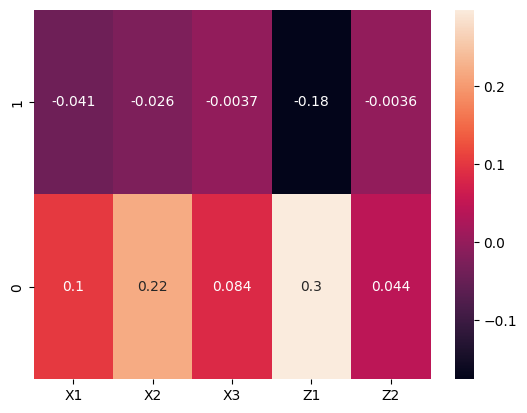

In [23]:
import seaborn as sns
def plot_heatmap_cluster_features(df,features_names):  
    def etalement(row):
        d = dict(row["top_features"])   
        for f in features_names:
            row[f] = d.get(f, 0.0)      
        return row

    df = df.apply(etalement, axis=1)[features_names]
    sns.heatmap(df,annot=True)

def plot_plain(emb, y,title="UMAP embedding (avant clustering)", s=10, alpha=0.7):
    plt.figure()
    plt.scatter(emb[:, 0], emb[:, 1], s=s,c=y, alpha=alpha)
    plt.title(title)
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.show()

plot_heatmap_cluster_features(df_do,FEATURES)

## 8) Notes pratiques

- Pour des Do‑Shapley plus stables : augmenter `n_perm` et `n_mc` (coût ↑).
- Pour plus de clusters : diminuer `min_cluster_size`/`min_samples`.
- Pour la comparaison Do vs Observé : garder **le même sous‑ensemble** d’observations.
